# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

First I define the following functions to **quickly inspect** an arbitrary object

In [2]:
## Helper function to inspect quickly the object by printing the methods
def class_methods(obj):
    methods = []
    for name in dir(obj):
        try:
            attr = getattr(obj, name)
            if callable(attr) and not name.startswith("__"):
                methods.append(name)
        except Exception:
            pass
    return methods


def print_obj_summary(obj,str = "obj"):
    print(f"\n Info about ",str," -> \n",
        "Class : ", obj,"\n",
        "Obj_attributess : ", vars(obj),"\n"
        "Relevant methods : ",class_methods(obj),"\n")
    


In [2]:
import gymnasium as gym

In [ ]:
# Instantiate a rendering and a non-rendering environment.
env_render = gym.make('CartPole-v1', render_mode = 'human')
env = gym.make('CartPole-v1',render_mode = None)
env_render = gym.make('CartPole-v1')
observation , info = env.reset()
print(f"Example of obseravation : ", observation ,"\n Info :",info)
## Observation is a ndarray


print_obj_summary(env,"env")
print_obj_summary(env.action_space,"action space")           ## we can move 2 directions
print_obj_summary(env.observation_space,"observation space") ## Observation space is a Discrete(2)

## Trying to sample from both spaces
print(f"sample from observation space ",env.observation_space.sample())
print(f"sample from action space ",env.action_space.sample())

## Trying to perform a step , ( Already called .reset() )
action = env.action_space.sample()
observation , reward , terminated , truncated , info  = env.step(action)
print("Reward obtaing in a single step is : ",reward,"\n")

## Finally simulationg one episode

terminated = False
env.reset()
step = 0
while not (terminated or truncated):
    action = env.action_space.sample()
    observation , reward , truncated , terminated , info  = env.step(action)
    step += 1
    print(f"Reward at step ",step,": ",reward)
    print(f"Info at step ",step,": ",info,"\n")
print("episode lasted for ",step," steps")

Example of obseravation :  [-0.01731525 -0.01248053  0.00820995  0.04596925] 
 Info : {}

 Info about  env  -> 
 Class :  <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>> 
 Obj_attributess :  {'_saved_kwargs': {'max_episode_steps': 500}, 'env': <OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>, '_action_space': None, '_observation_space': None, '_metadata': None, '_cached_spec': EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={'render_mode': None}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv'), '_max_episode_steps': 500, '_elapsed_steps': 0} 
Relevant methods :  ['class_name', 'close', 'get_wrapper_attr', 'has_wrapper_attr', 'render', 'reset', 'set_wrapper_attr', 'step', 'wrapper_spe

**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.



I decided to implement (refactor) the main algorith into different python modules.  
The structure is as follows:


<pre style="font-family: monospace; font-size: 14px;">
   src
    ├── device.py
    ├── evaluate.py
    ├── plot.py
    ├── policynet.py
    ├── reinforce.py
    ├── train.py
    ├── utils.py
    └── valuenet.py
</pre>


TODO descrizione dei moduli qui...

So first we import ours modules

In [ ]:
import numpy as np
from src.train import train
from src.policynet import PolicyNet
from src.device import device

**First** we define the seed , the CartPole env. and where we want to save the weights of our policy net

In [5]:
## seed = 1234  --w.o baseline with this seed i obtained a plateux of 9 on running reward
seed = 42
w_path = f"weights/{seed}"
v_path = f"videos/{seed}"
n_path = f"numeric/{seed}"
lr = 1e-3
num_episodes = 1000

We run our **traing loop** and collect the result including the metrics requested.

In [6]:
import os
def create_folders(*dirs):
    for dir in dirs:
        os.makedirs(dir,exist_ok=True)

with baseline = "mean" I am referring to the standardization done to the rewards 

In [6]:
# Running original implementation with baseline (i.e. standardize returns)

env = gym.make("CartPole-v1")
policy = PolicyNet(env).to(device)

baseline = "mean"
w_p_bs_mean = f"{w_path}/{baseline}/lr_{lr}"
v_p_bs_mean = f"{v_path}/{baseline}/lr_{lr}"
n_p_bs_mean = f"{n_path}/{baseline}/lr_{lr}"

create_folders(w_p_bs_mean,v_p_bs_mean,n_p_bs_mean)


## since I want to plot the results together I have to name differently these 3 following 
## variable otherwise I think the notebook will perform something I cannot control
## rr --> running reward , er --> eval_rewards , el --> eval_lenght

rr_bs_mean,er_bs_mean,el_bs_mean = train(
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        baseline = baseline,
        w_path = w_p_bs_mean,
        v_path = v_p_bs_mean,
        n_path = n_p_bs_mean,
        num_episodes = 1000
        )


started trainig with lr = 0.001
Applying baseline
Running reward: 0.6124
Running reward: 32.0321
Running reward: 44.6642
Running reward: 70.4465
Running reward: 81.3602
Running reward: 89.5582
Running reward: 91.1761
Running reward: 96.2058
Running reward: 97.0433
Running reward: 98.3594


/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/andrea/dev/DLA/3_DRL/videos/42/mean/lr_0.001 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Now we import our plots function (useful for now and later) to plot our results and define a commodity function to ease our work

In [9]:
%matplotlib inline
from src.plot import plot_results,plot_combined_results

def plot_single_results(rr,er,el):

    plot_results(
        (np.arange(1,len(rr)+1) , rr , "# episodes" , "running reward"),
        (np.arange(1,len(er)+1) , er , "# episodes" , "eval reward"),
        (np.arange(1,len(el)+1) , el , "# episodes" , "eval lenght"),
        show = True,
        save = False
    )

def plot_multiple_results(*methods):

    ## every 'method' passed shuold be in the form of (rr, er, el, label)
    
    method_triples = []
    for (rr, er, el, label) in methods:
        triples = [
            (np.arange(1, len(rr)+1), rr, "# episodes", "running reward", label),
            (np.arange(1, len(er)+1), er, "# episodes", "eval reward",   label),
            (np.arange(1, len(el)+1), el, "# episodes", "eval length",   label),
        ]
        method_triples.append(triples)

    plot_combined_results(*method_triples, show=True, save=False)




## Results

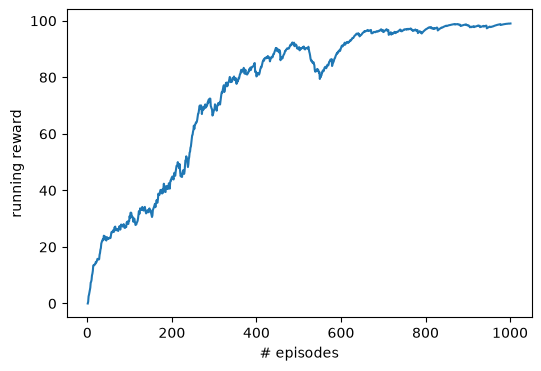

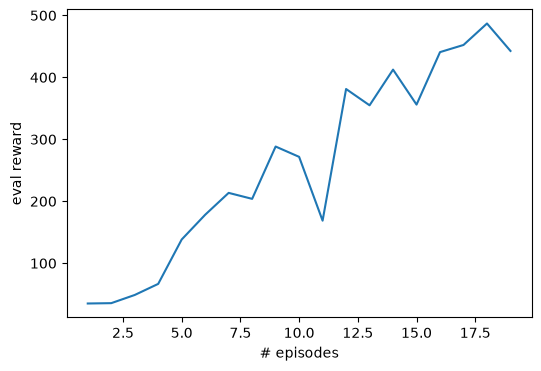

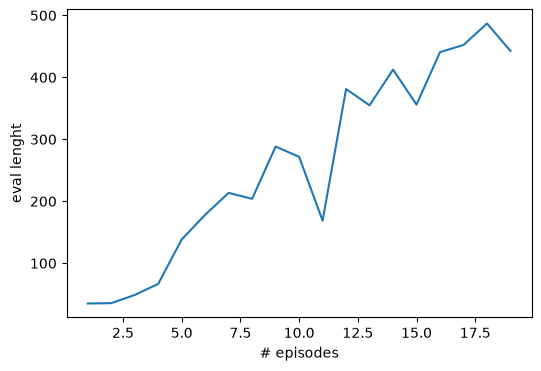

In [ ]:
### Plotting the results of baseline with mean 
plot_single_results(rr_bs_mean,er_bs_mean,el_bs_mean)

As we can see the eval reward reach the **maximum reward of 500** so CartPole is solved

-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

---

## Running code w.o baseline
- first with the **.sum()** in the loss function (  because in the implementation was done with .mean() -- I am aware that $\max \nabla_{x} x = \max (1/T) \nabla_{x} x$  but I wanted to try empirically  )

In [9]:
# Running vanilla implementation w.o baseline
## rr without _bs is indicating without baseline

env = gym.make("CartPole-v1")
policy = PolicyNet(env).to(device)

baseline = "no_baseline"
loss_op = "sum"

w_p_mean = f"{w_path}/{baseline}/{loss_op}/lr_{lr}"
v_p_mean = f"{v_path}/{baseline}/{loss_op}/lr_{lr}"
n_p_mean = f"{n_path}/{baseline}/{loss_op}/lr_{lr}"

create_folders(w_p_mean,w_p_mean,n_p_mean)


rr_sum,er_sum,el_sum = train(
        loss_op = loss_op,
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        baseline = None,
        w_path = w_p_mean,
        v_path = v_p_mean,
        n_path = n_p_mean,
        num_episodes = 1000
        )

started trainig with lr = 0.001
No baseline applied
Running reward: 0.5233
Running reward: 23.2341
Running reward: 34.2412
Running reward: 63.6368
Running reward: 90.0179
Running reward: 95.4113
Running reward: 96.7078
Running reward: 94.0497
Running reward: 97.0152
Running reward: 98.1953


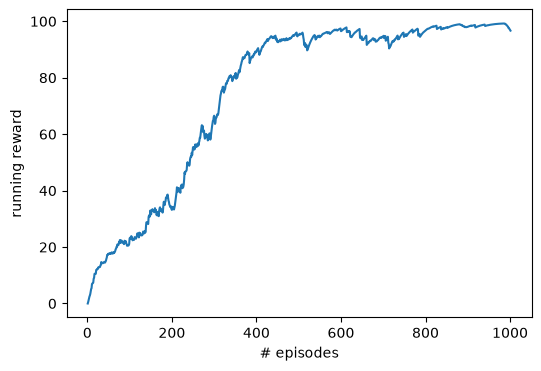

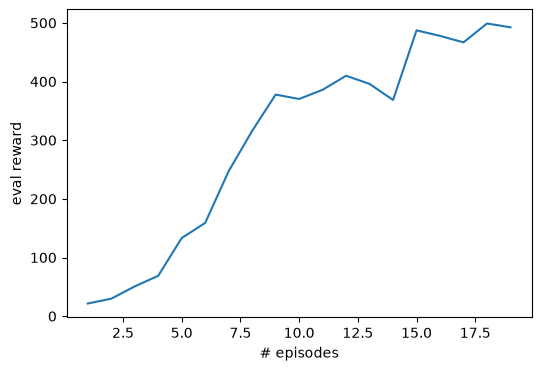

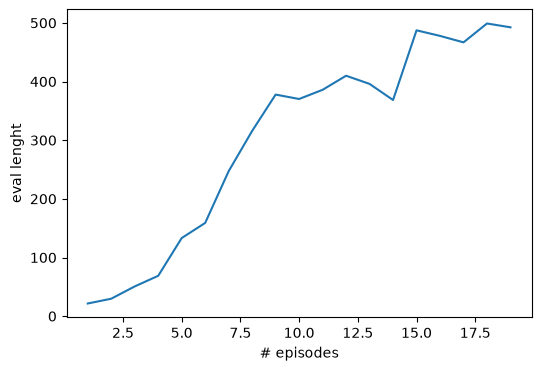

In [10]:
plot_single_results(rr_sum,er_sum,el_sum)

- now with the **.mean()**

In [ ]:
### running vanilla implementation with .mean() in the loss (I expect the training regime not to change that much)

env = gym.make("CartPole-v1")
policy = PolicyNet(env).to(device)

baseline = "no_baseline"
loss_op = "mean"

w_p_sum= f"{w_path}/{baseline}/{loss_op}/lr_{lr}"
v_p_sum = f"{v_path}/{baseline}/{loss_op}/lr_{lr}"
n_p_sum = f"{n_path}/{baseline}/{loss_op}/lr_{lr}"

create_folders(w_p_sum,v_p_sum,n_p_sum)


rr_mean,er_mean,el_mean = train(
        loss_op = loss_op,
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        baseline = None,
        w_path = w_p_sum,
        v_path = v_p_sum,
        n_path = n_p_sum,
        num_episodes = 1000
        )

started trainig with lr = 0.001
No baseline applied
Running reward: 0.5233
Running reward: 22.4857
Running reward: 21.3727
Running reward: 21.7265
Running reward: 32.7310
Running reward: 45.9489
Running reward: 67.0361
Running reward: 78.8673
Running reward: 76.6278
Running reward: 83.8942


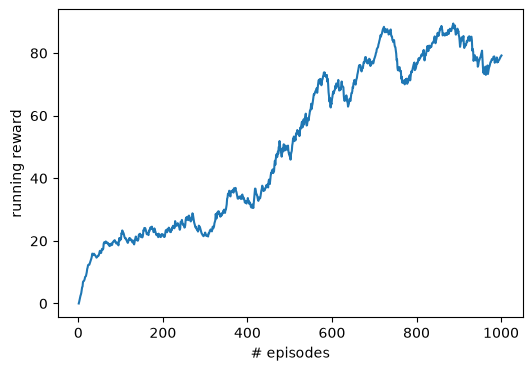

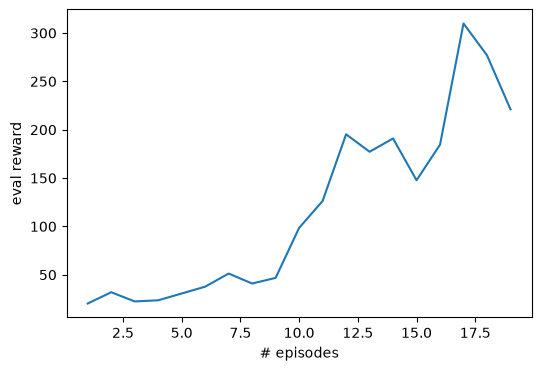

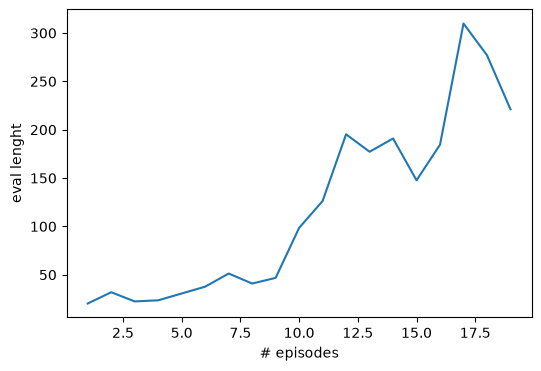

In [15]:
plot_single_results(rr_mean,er_mean,el_mean)

Now let's plot everything togheter for a comparison

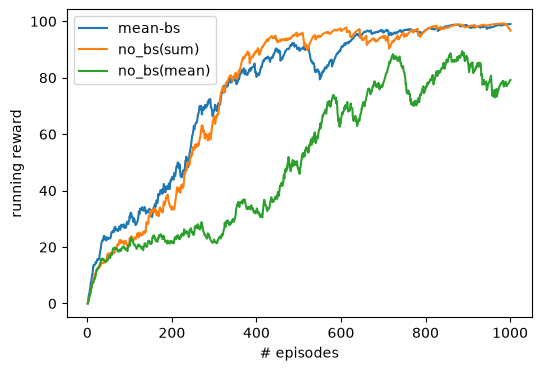

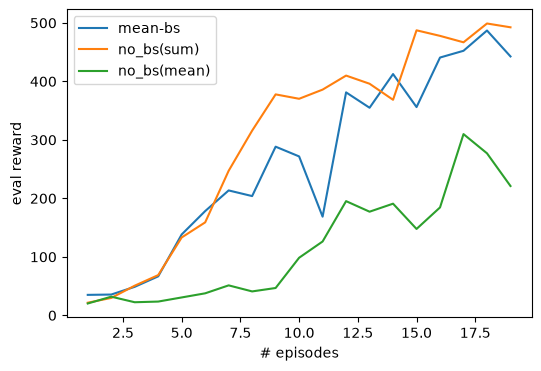

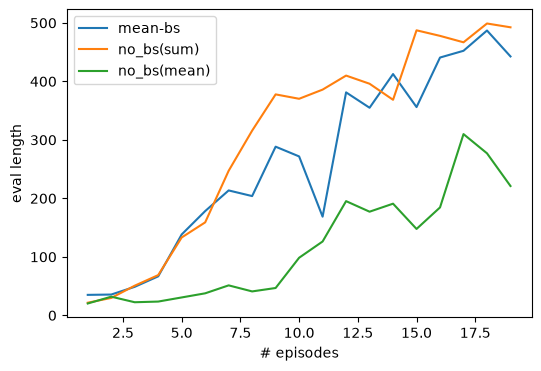

In [16]:
plot_multiple_results(  (rr_bs_mean,er_bs_mean,el_bs_mean,"mean-bs"),
                        (rr_sum,er_sum,el_sum,"no_bs(sum)"),
                        (rr_mean,er_mean,el_mean,"no_bs(mean)"))

no_bs(sum) and mean basline achieve the **(almost)same performce** (here no_ns(sum) did slightly better)  no_bs(mean) basically does not resolve cart-Pole within the same number of episodes

---

**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

---

here basically a reuse the same code as above as inside my modules ```baseline``` argument can be passed as both string and callable object so that I can handle different type of baselines

In [1]:
from src.train import train

pygame 2.6.1 (SDL 2.28.4, Python 3.13.11)
Hello from the pygame community. https://www.pygame.org/contribute.html
Currently available device:  cuda


/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [ ]:
from src.valuenet import ValueNet

env = gym.make("CartPole-v1")

policy = PolicyNet(env).to(device)
value_net = ValueNet(env).to(device)

baseline_string = "valuenet" 
loss_op = "mean"

lr_vnet = 1e-3

w_p_vnet= f"{w_path}/{baseline_string}/{loss_op}/lr_{lr}"
v_p_vnet = f"{v_path}/{baseline_string}/{loss_op}/lr_{lr}"
n_p_vnet = f"{n_path}/{baseline_string}/{loss_op}/lr_{lr}"

create_folders(w_p_vnet, v_p_vnet, n_p_vnet)

rr_vnet, er_vnet, el_vnet = train(
        loss_op = loss_op,
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        lr_vnet = lr_vnet,
        baseline = value_net,  
        w_path = w_p_vnet,
        v_path = v_p_vnet,
        n_path = n_p_vnet,
        num_episodes = 1000
)

started trainig with lr = 0.001
Applying baseline


/home/andrea/dev/DLA/3_DRL/src/reinforce.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs_tensor = torch.tensor(torch.stack(obs), dtype=torch.float32)


Running reward: 0.5233
Running reward: 28.0239
Running reward: 34.8418
Running reward: 72.1031
Running reward: 88.6887
Running reward: 96.6711
Running reward: 98.5421
Running reward: 99.0291
Running reward: 95.2373
Running reward: 99.2478


/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/andrea/dev/DLA/3_DRL/videos/42/valuenet/mean/lr_0.001 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


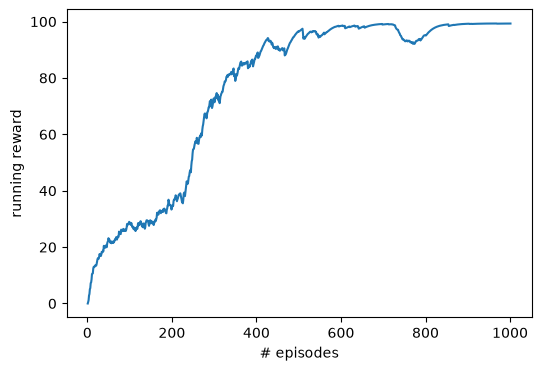

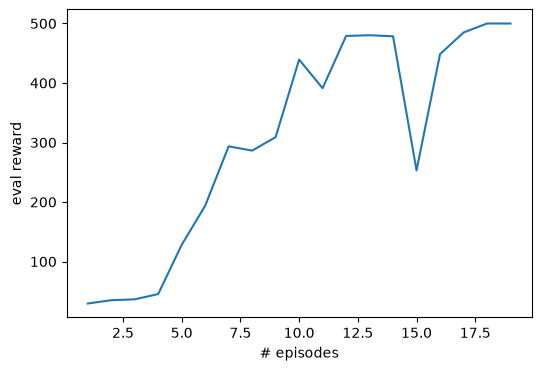

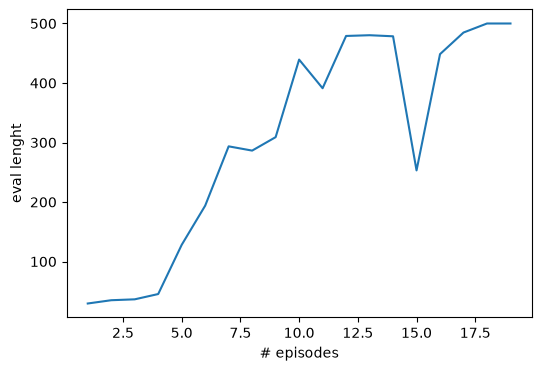

In [10]:
plot_single_results(rr_vnet,er_vnet,el_vnet)

## Comparing results

Plotting everethying together

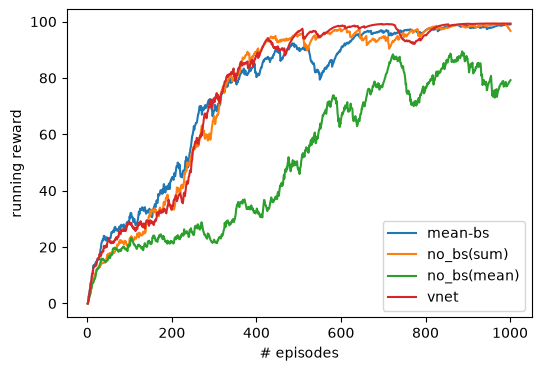

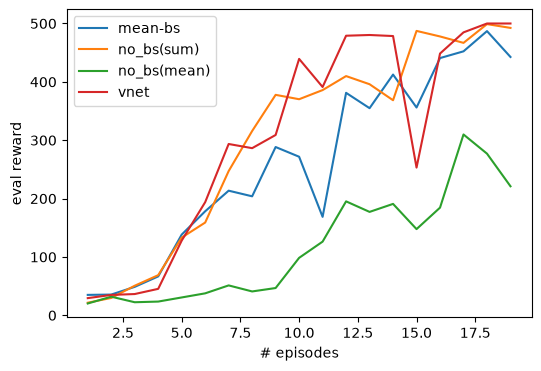

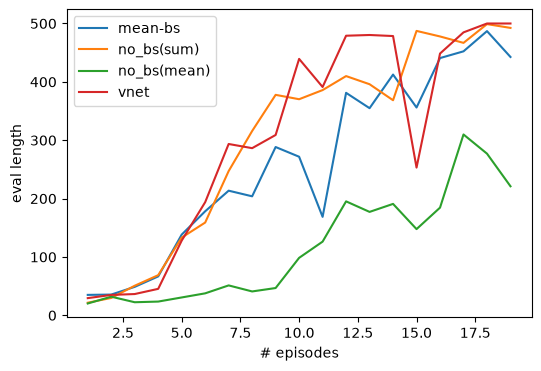

In [ ]:
#### we load the data 

n_path_base = f"numeric/{seed}"
learning_rate = lr


# 1. "mean-bs"
path_mean_bs = f"{n_path_base}/mean/lr_{learning_rate}"
rr_bs_mean = np.load(f"{path_mean_bs}/running_rewards.npy")
er_bs_mean = np.load(f"{path_mean_bs}/eval_rewards.npy")
el_bs_mean = np.load(f"{path_mean_bs}/eval_lenght.npy")

# 2. "no_bs(sum)" (Baseline: "no_baseline", Loss: "sum")
path_no_bs_sum = f"{n_path_base}/no_baseline/sum/lr_{learning_rate}"
rr_sum = np.load(f"{path_no_bs_sum}/running_rewards.npy")
er_sum = np.load(f"{path_no_bs_sum}/eval_rewards.npy")
el_sum = np.load(f"{path_no_bs_sum}/eval_lenght.npy")

# 3. "no_bs(mean)" (Baseline: "no_baseline", Loss: "mean")
path_no_bs_mean = f"{n_path_base}/no_baseline/mean/lr_{learning_rate}"
rr_mean = np.load(f"{path_no_bs_mean}/running_rewards.npy")
er_mean = np.load(f"{path_no_bs_mean}/eval_rewards.npy")
el_mean = np.load(f"{path_no_bs_mean}/eval_lenght.npy")

# 4. "vnet" (Baseline: "valuenet", Loss: "mean")
path_vnet = f"{n_path_base}/valuenet/mean/lr_{learning_rate}"
rr_vnet = np.load(f"{path_vnet}/running_rewards.npy")
er_vnet = np.load(f"{path_vnet}/eval_rewards.npy")
el_vnet = np.load(f"{path_vnet}/eval_lenght.npy")



plot_multiple_results(
    (rr_bs_mean, er_bs_mean, el_bs_mean, "mean-bs"),
    (rr_sum, er_sum, el_sum, "no_bs(sum)"),
    (rr_mean, er_mean, el_mean, "no_bs(mean)"),
    (rr_vnet, er_vnet, el_vnet, "vnet")
)

We can say that the **vnet basline** achives the **highest eval reward** and matches no_bs(sum) and mean_bs on running reward . In general I haven't talked about episodic (val) lenght because its values are the same of the eval reward (This comes from the reward mechanism as the stick gets +1 for every step that is still up ).

Last thing last here there is gif showing how well the agent trained with mean-bs is performing 

![Agent RunCartPole](gifs/videos_cartpole.gif)


-----

## Exercise 3: Going Deeper

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.

---
 

### Folder structure

<pre style="font-family: monospace; font-size: 14px; line-height: 1.2;">
<span style="color:#4285f4"><b>OpenAIcar/</b></span>
├── main.py
├── <span style="color:#4285f4"><b>runs/</b></span>
│   ├── <span style="color:#4285f4"><b>CarRacing-v3__seed_1__1781975163/</b></span>
│   ├── <span style="color:#4285f4"><b>CarRacing-v3__seed_2__1782072789/</b></span>
│   └── <span style="color:#4285f4"><b>CarRacing-v3__seed_3__1782169642/</b></span>
│   
└── <span style="color:#4285f4"><b>src/</b></span>
    ├── buffer.py
    ├── config.py
    ├── env_wrapper.py
    ├── models.py
    └── trainer.py
</pre>


In the following cell I defined a function to **evaluate the model and register a video with it**

In [19]:
import gymnasium as gym
import torch
import numpy as np
from gymnasium.wrappers import GrayscaleObservation, FrameStackObservation, ResizeObservation, RecordVideo
from IPython.display import Video, display
import os

from OpenAIcar.src.models import CNNDiscreteAgent

def record_and_display_video(model_path,name_prefix,video_folder="videos_car",gym_id="CarRacing-v3"):

    env = gym.make(gym_id, continuous=False, render_mode="rgb_array")
    
    os.makedirs(video_folder, exist_ok=True)
    env = RecordVideo(
        env, 
        video_folder=video_folder, 
        name_prefix=name_prefix,
        episode_trigger=lambda x: True 
    )
    
    env = GrayscaleObservation(env, keep_dim=False)
    env = ResizeObservation(env, (84, 84)) 
    env = FrameStackObservation(env, 4)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    obs_shape = env.observation_space.shape
    action_dim = env.action_space.n
    
    agent = CNNDiscreteAgent(obs_shape, action_dim).to(device)
    
    checkpoint = torch.load(model_path, map_location=device,weights_only=False)
    agent.load_state_dict(checkpoint['agent_state_dict'])
    agent.eval()

    obs, info = env.reset()
    
    done = False
    episodic_return = 0

    while not done:
        obs_tensor = torch.tensor(np.array([obs])).to(device)
        obs_tensor = obs_tensor.float()/255

        with torch.no_grad():
            hidden = agent.network(obs_tensor)
            
            logits = agent.actor(hidden)
            
            action = torch.argmax(logits, dim=1)

        action_np = action.cpu().numpy()[0]

        next_obs, reward, terminated, truncated, info = env.step(action_np)
        done = np.logical_or(terminated, truncated)

        episodic_return += reward
        obs = next_obs

    env.close()
    print(f"Register video  with the following return : {episodic_return:.2f}")

    video_path = f"{video_folder}/{name_prefix}-episode-0.mp4"
    return Video(video_path, embed=True, html_attributes="controls autoplay loop")

Let's test our **trained car**...

In [ ]:
model_file_path = "OpenAIcar/runs/CarRacing-v3__seed_1__1781975163/checkpoints/best_model.pt"
video_widget = record_and_display_video(model_file_path,video_folder="videos_car1",name_prefix="best")
display(video_widget)

Register video  with the following return : 826.67

![Agent Run1](gifs/videos_car1.gif)

It kinda works but the driver is a bit reckless,so I tried to train it on a clipped reward 
(**np.clip(reward,max=1.0)**)to see if the car effectevly slows down...

In [ ]:
model_file_path = "OpenAIcar/runs/CarRacing-v3__seed_2__1782072789/checkpoints/best_model.pt"
video_widget = record_and_display_video(model_file_path,video_folder ="videos_car_2",name_prefix="best_seed2")
display(video_widget)

Register video  with the following return : 656.10


![Agent Run2](gifs/videos_car2.gif)

And... it didn't work (it keeps going **too fast**).
So I built a wrapper around the Enviroment to specifically **discourage some weird movements** such as **right to left** and **left to right** (in a short time period) and then I gave the agent -0.25 if it **kept accelerating** over some continuous frames. 

In [ ]:
model_file_path = "OpenAIcar/runs/CarRacing-v3__seed_3__1782169642/checkpoints/best_model.pt"
video_widget = record_and_display_video(model_file_path,video_folder ="videos_car_3",name_prefix="best_seed3")
display(video_widget)

/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/andrea/dev/DLA/3_DRL/videos_car_3 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Register video  with the following return : 870.70


![Agent Run3](gifs/videos_car3.gif)

I wanted to test the model more...(maybe a whole lap could be nice)

In [ ]:
model_file_path = "OpenAIcar/runs/CarRacing-v3__seed_3__1782169642/checkpoints/best_model.pt"
video_widget = record_and_display_video(model_file_path,video_folder ="videos_car_4",name_prefix="best_seed4")
display(video_widget)

Register video  with the following return : 867.85


![Agent Run4](gifs/videos_car4.gif)

It worked for that specific trace but generally I noted that the car still **keeps accelerating too much on the straights and goes offthe track when there's a hairpin corners**.(Sometimes it also come back in track).

---

## Quantitative Results

**Episodic lenghts** (Number of steps taken in an episode.)

<div style="text-align: left;">
    <img src="car_race_results/lenghts.png" width="900" alt="Loss Curve">
</div>


and **episodic returns** (Total cumulative reward obtained in an episode.)

<div style="text-align: left;">
    <img src="car_race_results/returns.png" width="900" alt="Loss Curve">
</div>

**mean (last 20) episodic returns** (Average episode return over the last 20 episodes).

<div style="text-align: left;">
    <img src="car_race_results/mean_20_returns.png" width="900" alt="Loss Curve">
</div>

This graph are screeshots from tensorboard.
I also traced other metrics and can be accessed using tensorboard with the following command  
``` tensorboard --logdir runs ```


For the experiments showed I used this tree following commands

- **orange line (first implementation)**    
``` python main.py --gym-id CarRacing-v3 --num-envs 8 --num-steps 512 --total-timesteps 2000000 --checkpoint-freq 50 ```  

- **blue line (clipped reward)**   
``` python main.py --gym-id CarRacing-v3 --num-envs 8 --num-steps 512 --total-timesteps 4000000 --checkpoint-freq 50 --seed 2```

- **light blue line (custom enviroment)**  
``` python main.py --gym-id CarRacing-v3 --num-envs 8 --num-steps 512 --total-timesteps 6000000 --checkpoint-freq 50 --seed 3```

The highest mean(20) episodic return was obtained by the third experiment with a value of **881 by the blue line** (Considering that for an episode the **maximum reward possible is 900**)



---

Here there are **some mathematical consideration** that I went through when I faced this notebook to better understand the task

### Reinforce Alg. — Thoughts

#### Objective

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \gamma^t r_t\right], \quad \tau = (s_0, a_0, r_0, s_1, \ldots)$$

#### Policy Gradient

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot \underbrace{G_t}_{\text{return from timestamp } t}\right]$$

#### trajectory probability

$$p(\tau | \theta) = \prod_{t=0}^{T} \pi_\theta(a_t | s_t) \cdot p(s_{t+1} | s_t, a_t)$$

Taking the log and separating into A and B term:

$$\log p(\tau | \theta) = \sum_{t=0}^{T} \log\!\left(\underbrace{\pi_\theta(a_t|s_t)}_{A} \cdot \underbrace{p(s_{t+1}|s_t, a_t)}_{B}\right) = \sum \log A + \sum \log B$$

deriving w.r.t  θ (B does not depend on θ):

$$\nabla_\theta \log p(\tau | \theta) = \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t)$$

---

### REINFORCE

Approximation with **one sample** (1 episode), because  in **(1)** we should have considered all trajectories.

$$\nabla_\theta J(\theta) \approx \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot G_t \quad \longrightarrow \text{high variance}$$

Loss :

$$\mathcal{L}(\theta) = -\sum_t \log \pi_\theta(a_t | s_t) \cdot G_t$$

---

#### With Baseline

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t | s_t)(G_t - b(s_t))\right]$$

where $b(s_t)$ **does not depend on actions**.  
Dimostration that the expectation is zero :  

$$\mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot b(s_t)\right]$$

$$= \int b(s_t) \cdot \nabla_\theta \log \pi_\theta(\cdot) \cdot \pi_\theta(a|s_t)\, da$$

$$= \int b(s_t) \cdot \nabla_\theta \pi_\theta(a|s_t)\, da$$

$$= b(s_t) \cdot \nabla_\theta \underbrace{\int \pi_\theta(a|s_t)\, da}_{=1} = 0$$

### In the code we use

$$\tilde{G}_t = \frac{G_t - \mu_G}{\sigma_G + \varepsilon} \quad \text{and then } \texttt{.mean()} \text{ in the loss}$$

$$\nabla_\theta \mathcal{L} \approx \frac{1}{T} \sum_t \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot \tilde{G}_t$$

> so our baseline is  $\bar{G}_t$ or $\text{mean}(G_t)$

---

### References
https://huggingface.co/blog/deep-rl-ppo  
https://github.com/vwxyzjn/ppo-implementation-details  
https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/

### AI usage
https://gemini.google.com/gem/2ef1a390987d/4de7e99c4b23f19a  
https://gemini.google.com/gem/coding-partner/987d07ccc8c8eac9

